In [1]:
# Load the results from the sweeps (files in ./results/) and visualize performance over hyperparameters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import display, HTML

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## Load data

In [2]:
# Set the results directory path
results_dir = './results/sim_sweep1_seed*.csv'
#results_dir = './results/sim_sweep*_adapter*.csv'

# Find all CSV files in the results directory
csv_files = glob.glob(results_dir)
print(f"Found {len(csv_files)} CSV files in the results directory.")

# Group files by type (train, regression, classification)
train_files = [f for f in csv_files if 'train' in f.lower()]
regression_files = [f for f in csv_files if 'regression' in f.lower()]
classification_files = [f for f in csv_files if 'classification' in f.lower()]
#rank_files = [f for f in csv_files if 'rank' in f.lower()]
rank_files = [f for f in csv_files if 'analysis' in f.lower()]
hyperparams_files = [f for f in csv_files if 'hyperparams' in f.lower()]

print(f"Train files: {len(train_files)}")
print(f"Regression files: {len(regression_files)}")
print(f"Classification files: {len(classification_files)}")
print(f"Rank files: {len(rank_files)}")
print(f"Hyperparams files: {len(hyperparams_files)}")

Found 15 CSV files in the results directory.
Train files: 3
Regression files: 3
Classification files: 3
Rank files: 3
Hyperparams files: 3


In [3]:
# Load all the regression data
regression_dfs = []
for file in regression_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    regression_dfs.append(df)

# Combine all regression data
if regression_dfs:
    regression_df = pd.concat(regression_dfs, ignore_index=True)
    print(f"Loaded regression data: {regression_df.shape[0]} rows, {regression_df.shape[1]} columns")
    display(regression_df.head())
else:
    regression_df = None
    print("No regression data found.")

Loaded regression data: 5184 rows, 6 columns


,name,r2_mean,r2_std,run_iter,seed,source_file
0,Zm1,0.852005,0.123571,0,0,sim_sweep1_seed0_regression.csv
1,Zs1,0.720469,0.173813,0,0,sim_sweep1_seed0_regression.csv
2,(Zm+Zs)1,0.981080,0.014931,0,0,sim_sweep1_seed0_regression.csv
3,Zm2,0.807422,0.201352,0,0,sim_sweep1_seed0_regression.csv
4,Zs2,0.483459,0.350281,0,0,sim_sweep1_seed0_regression.csv


In [4]:
# Load all the classification data
classification_dfs = []
for file in classification_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    classification_dfs.append(df)

# Combine all classification data
if classification_dfs:
    classification_df = pd.concat(classification_dfs, ignore_index=True)
    print(f"Loaded classification data: {classification_df.shape[0]} rows, {classification_df.shape[1]} columns")
    display(classification_df.head())
else:
    classification_df = None
    print("No classification data found.")

Loaded classification data: 3456 rows, 9 columns


,name,accuracy,precision,recall,f1,roc_auc,run_iter,seed,source_file
0,Zs1,0.896,0.899511,0.892,0.895465,0.896,0,0,sim_sweep1_seed0_classification.csv
1,Zs2,0.868,0.876498,0.858,0.866544,0.868,0,0,sim_sweep1_seed0_classification.csv
2,Zm1,0.991,0.984275,0.998,0.991074,0.991,0,0,sim_sweep1_seed0_classification.csv
3,Zm2,0.950,0.954105,0.946,0.949828,0.950,0,0,sim_sweep1_seed0_classification.csv
4,Zs1,0.976,0.976094,0.976,0.975979,0.976,1,0,sim_sweep1_seed0_classification.csv


In [5]:
# same for rank
rank_dfs = []
for file in rank_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    rank_dfs.append(df)

# Combine all rank data
if rank_dfs:
    rank_df = pd.concat(rank_dfs, ignore_index=True)
    print(f"Loaded rank data: {rank_df.shape[0]} rows, {rank_df.shape[1]} columns")
    display(rank_df.head())
else:
    rank_df = None
    print("No rank data found.")

Loaded rank data: 5184 rows, 6 columns


,name,metric,value,run_iter,seed,source_file
0,R_s-R_m1,correlation,-0.036224,0,0,sim_sweep1_seed0_analysis.csv
1,R_s-R_m2,correlation,-0.068096,0,0,sim_sweep1_seed0_analysis.csv
2,R_m1-R_m2,correlation,0.124011,0,0,sim_sweep1_seed0_analysis.csv
3,R_s,rank,2.000000,0,0,sim_sweep1_seed0_analysis.csv
4,R_m1,rank,4.000000,0,0,sim_sweep1_seed0_analysis.csv


In [6]:
train_dfs = []
for file in train_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    #df['source_file'] = os.path.basename(file)
    #df['seed'] = file.split('_seed')[-1].split('_')[0]
    train_dfs.append(df)
# Combine all train data
if train_dfs:
    train_df = pd.concat(train_dfs, ignore_index=True)
    print(f"Loaded train data: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
    #cols_for_name = ['batch_size', 'learning_rate', 'lr_annealing', 'weight_decay', 'specific_rank', 'shared_rank', 'seed']
    #train_df['model_name'] = train_df[cols_for_name].astype(str).agg('-'.join, axis=1)
    display(train_df.head())
else:
    train_df = None
    print("No train data found.")

Loaded train data: 448794 rows, 7 columns


,Shared Loss,Orthogonal Loss,Mutual Info Loss,stage,epoch,run_iter,seed
0,-0.405762,21.262497,8.376205,shared,0,0,0
1,-0.415567,21.365283,8.305288,shared,1,0,0
2,-0.421141,21.473505,8.313205,shared,2,0,0
3,-0.435543,21.585187,8.259854,shared,3,0,0
4,-0.442730,21.703343,8.237180,shared,4,0,0


In [7]:
hyperparams_dfs = []
for file in hyperparams_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    #df['source_file'] = os.path.basename(file)
    hyperparams_dfs.append(df)
# Combine all hyperparams data
if hyperparams_dfs:
    hyperparams_df = pd.concat(hyperparams_dfs, ignore_index=True)
    print(f"Loaded hyperparams data: {hyperparams_df.shape[0]} rows, {hyperparams_df.shape[1]} columns")
    display(hyperparams_df.head())
else:
    hyperparams_df = None
    print("No hyperparams data found.")

Loaded hyperparams data: 864 rows, 17 columns


,batch_size,learning_rate,weight_decay,weight_init,lr_annealing,n_specific_rank,n_shared_rank,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2,max_epochs,staging,pruning,z_ortho_loss,model_number,seed
0,128,0.0001,0.0001,uniform,linear,4,4,10,20,0.010,0.005,1000,True,True,False,0,346
1,128,0.0001,0.0001,uniform,linear,4,4,10,20,0.010,0.001,1000,True,True,False,1,346
2,128,0.0001,0.0001,uniform,linear,4,4,10,20,0.005,0.005,1000,True,True,False,2,346
3,128,0.0001,0.0001,uniform,linear,4,4,10,20,0.005,0.001,1000,True,True,False,3,346
4,128,0.0001,0.0001,uniform,linear,4,4,10,50,0.010,0.005,1000,True,True,False,4,346


## Functions

In [8]:
def plot_score_by_hyperparam(df, param, metric='r2_mean', metric_type='column'):
    if df is None:
        print("No data available.")
        return
    
    if param not in df.columns or (metric not in df.columns and metric_type == 'column'):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif param not in df.columns or (metric_type == 'value' and metric not in df['metric'].values):
        print(f"Either {param} or {metric} not found in data.")
        return
    elif metric_type not in ['column', 'value']:
        print(f"Invalid metric type: {metric_type}. Use 'column' or 'value'.")
        return
    
    # Check if there's more than one unique value for this hyperparameter
    unique_values = df[param].unique()
    if len(unique_values) <= 1:
        print(f"Skipping plots for {param} because there is only one unique value: {unique_values}")
        return
    
    # Create one bar plot for component performances grouped by the hyperparameter
    plt.figure(figsize=(8, 3))
    
    if metric_type == 'column':
        sns.barplot(x='name', y=metric, hue=param, data=df,
                    errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df[metric].min() - 0.1, df[metric].max() + 0.1)
    else:
        df = df[df['metric'] == metric]
        sns.barplot(x='name', y='value', hue=param, data=df,
                    errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        # set y limits to min and max of the metric
        #plt.ylim(df['value'].min() - 0.1, df['value'].max() + 0.1)
    
    plt.title(f'Average Score by {param}')
    plt.ylabel(f'Score ({metric})')
    plt.xlabel('Representation Component')
    plt.xticks(rotation=45)
    plt.legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Learning curves

In [9]:
# add the hyperparams to the train data
hyperparams = hyperparams_df.columns[:-2].tolist()

train_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the train data
    train_dfs_hyperparams.append(train_df[train_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
train_df_hyperparams = pd.concat(train_dfs_hyperparams, ignore_index=True)
display(train_df_hyperparams.head())

,Shared Loss,Orthogonal Loss,Mutual Info Loss,stage,epoch,run_iter,seed,batch_size,learning_rate,weight_decay,...,n_specific_rank,n_shared_rank,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2,max_epochs,staging,pruning,z_ortho_loss
0,-0.405762,21.262497,8.376205,shared,0,0,0,128,0.0001,0.0001,...,4,4,10,20,0.01,0.005,1000,True,True,False
1,-0.415567,21.365283,8.305288,shared,1,0,0,128,0.0001,0.0001,...,4,4,10,20,0.01,0.005,1000,True,True,False
2,-0.421141,21.473505,8.313205,shared,2,0,0,128,0.0001,0.0001,...,4,4,10,20,0.01,0.005,1000,True,True,False
3,-0.435543,21.585187,8.259854,shared,3,0,0,128,0.0001,0.0001,...,4,4,10,20,0.01,0.005,1000,True,True,False
4,-0.442730,21.703343,8.237180,shared,4,0,0,128,0.0001,0.0001,...,4,4,10,20,0.01,0.005,1000,True,True,False


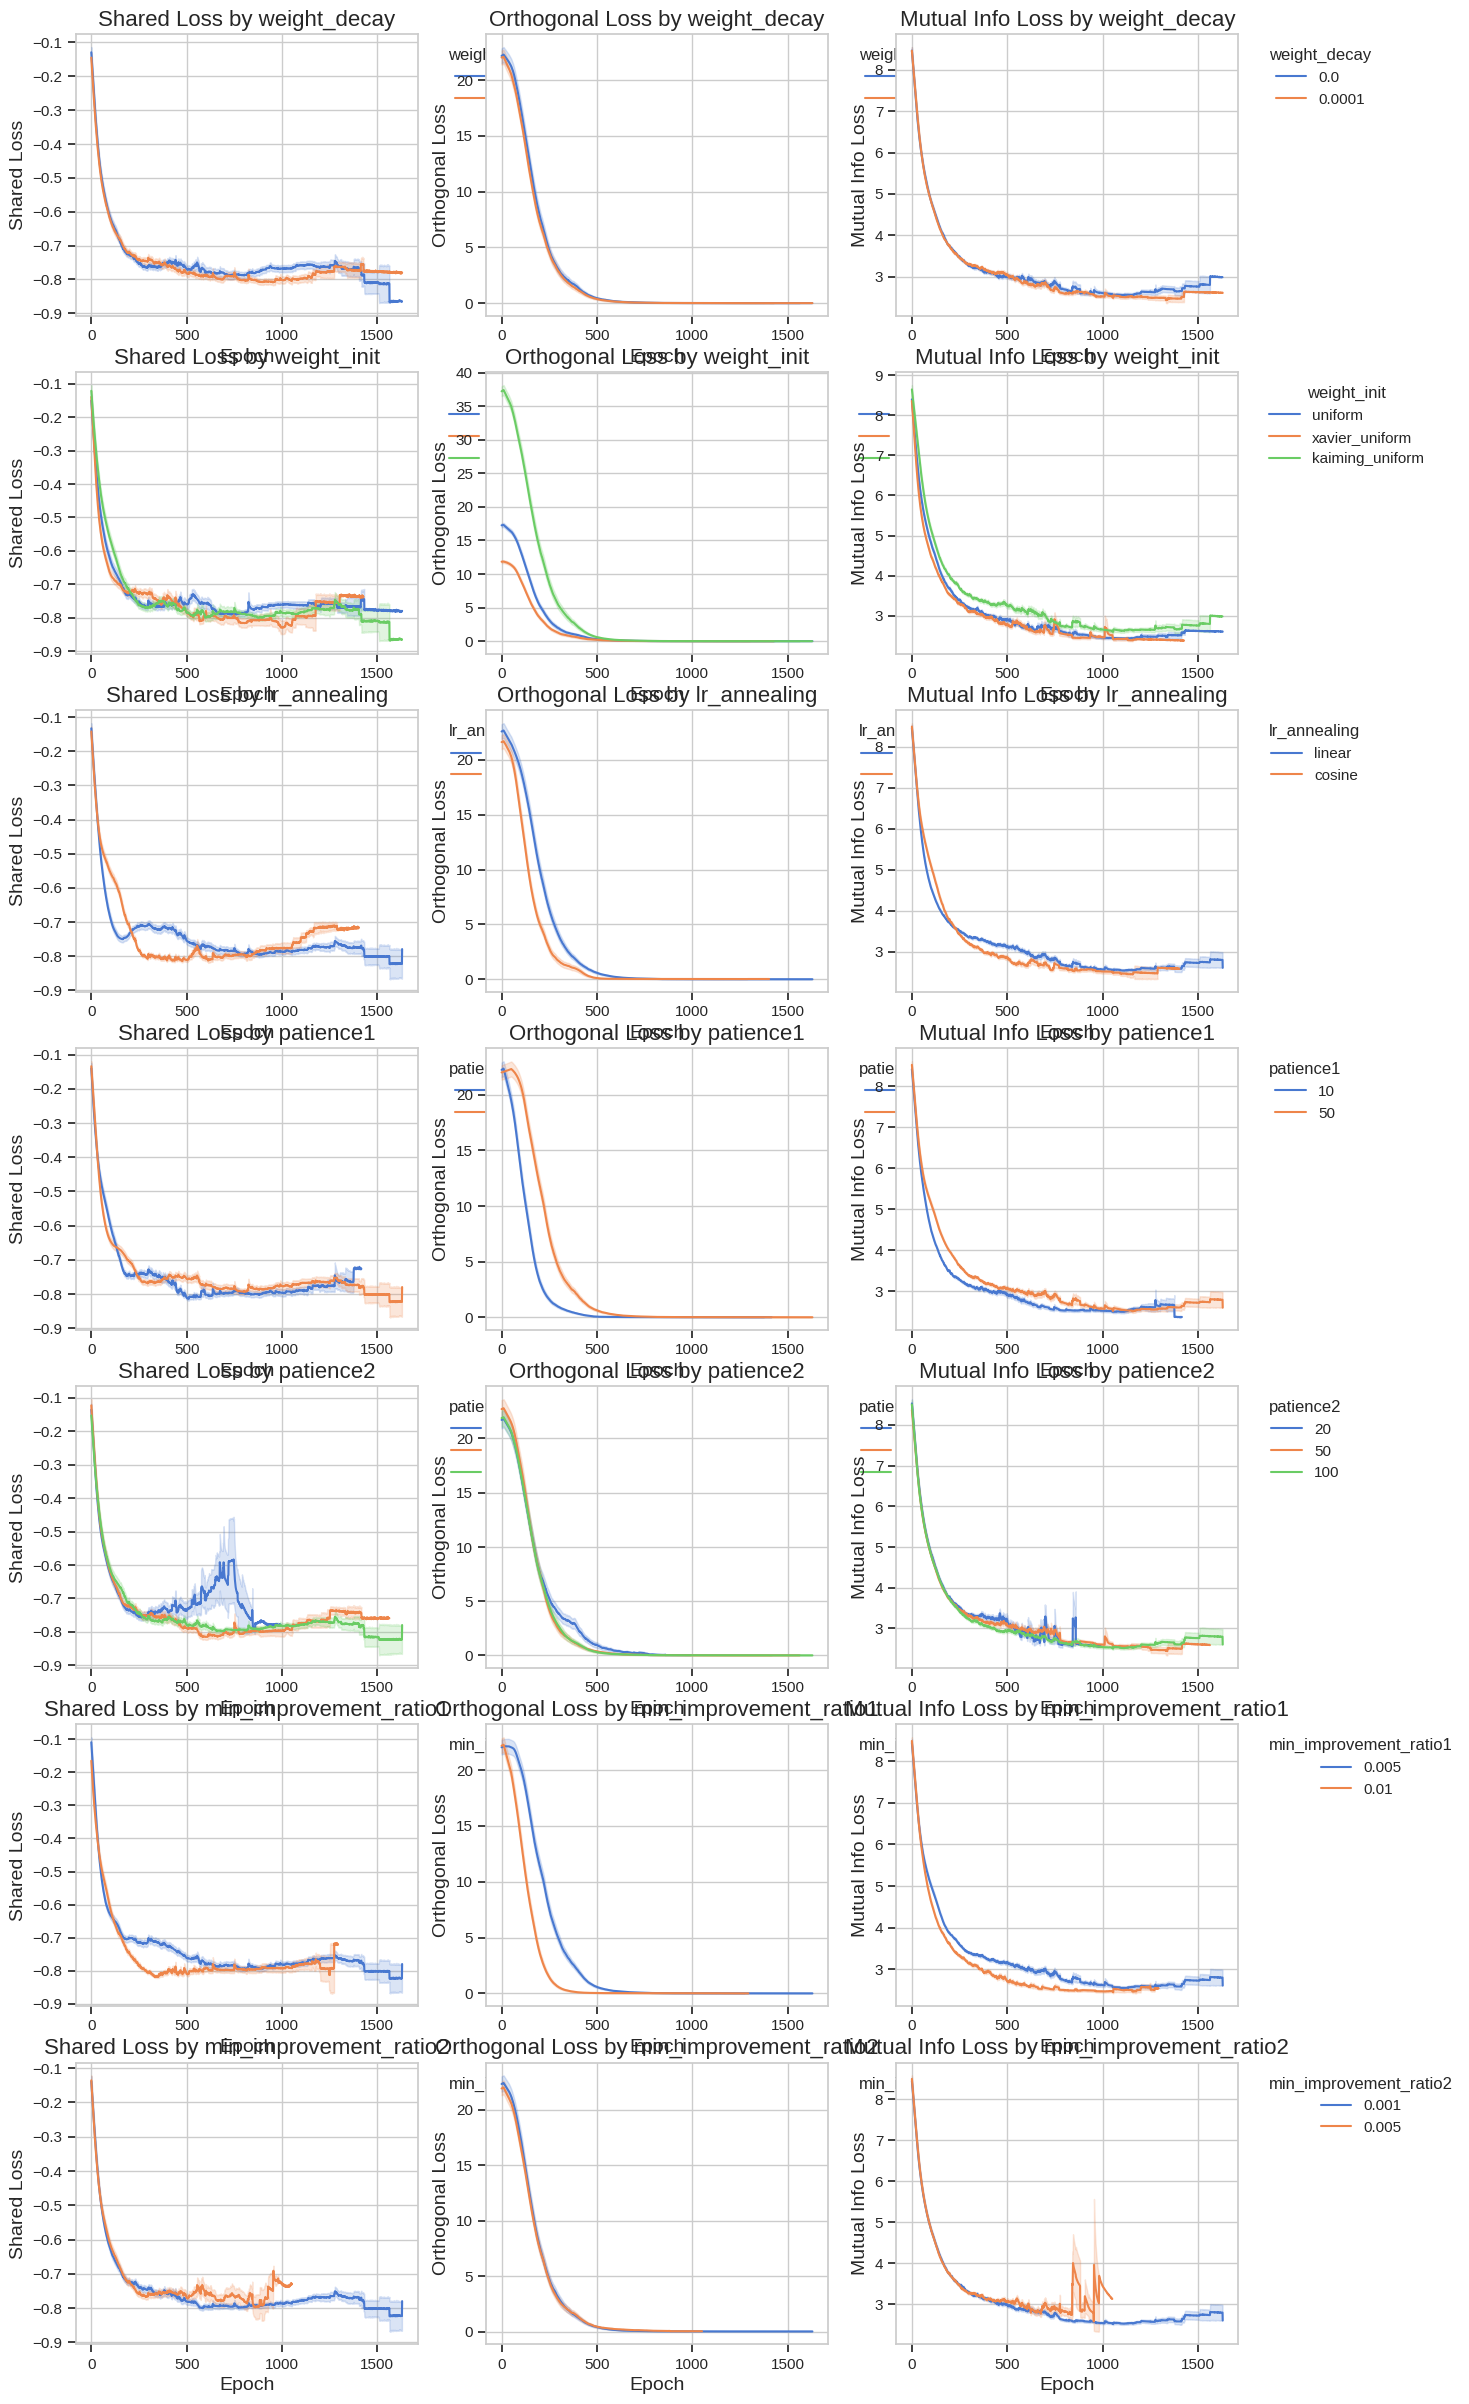

In [10]:
loss_columns = ['Shared Loss', 'Orthogonal Loss', 'Mutual Info Loss']
#loss_columns = ['Sparsity Loss', 'Orthogonal Loss', 'Mutual Info Loss']
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
# remove 'model_number' and 'run_iter' from the hyperparams
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

fig, axs = plt.subplots(len(hyperparams), len(loss_columns), figsize=(15,30))

for i in range(len(loss_columns)):
    for j in range(len(hyperparams)):
        sns.lineplot(data=train_df_hyperparams, x='epoch', y=loss_columns[i], ax=axs[j, i], hue=hyperparams[j], palette='muted', errorbar='se')
        axs[j, i].set_title(f'{loss_columns[i]} by {hyperparams[j]}')
        axs[j, i].set_xlabel('Epoch')
        axs[j, i].set_ylabel(loss_columns[i])
        axs[j, i].legend(title=hyperparams[j], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Accuracy

In [11]:
# add the hyperparams to the train data
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

class_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the classification data
    class_dfs_hyperparams.append(classification_df[classification_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
class_df_hyperparams = pd.concat(class_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
display(class_df_hyperparams.head())

,name,accuracy,precision,recall,f1,roc_auc,run_iter,seed,source_file,weight_decay,weight_init,lr_annealing,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2
0,Zs1,0.896,0.899511,0.892,0.895465,0.896,0,0,sim_sweep1_seed0_classification.csv,0.0001,uniform,linear,10,20,0.01,0.005
1,Zs2,0.868,0.876498,0.858,0.866544,0.868,0,0,sim_sweep1_seed0_classification.csv,0.0001,uniform,linear,10,20,0.01,0.005
2,Zm1,0.991,0.984275,0.998,0.991074,0.991,0,0,sim_sweep1_seed0_classification.csv,0.0001,uniform,linear,10,20,0.01,0.005
3,Zm2,0.950,0.954105,0.946,0.949828,0.950,0,0,sim_sweep1_seed0_classification.csv,0.0001,uniform,linear,10,20,0.01,0.005
4,Zs1,0.983,0.978651,0.988,0.983121,0.983,0,42,sim_sweep1_seed42_classification.csv,0.0001,uniform,linear,10,20,0.01,0.005


/tmp/ipykernel_1028117/4076022226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y=metric, data=classification_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)


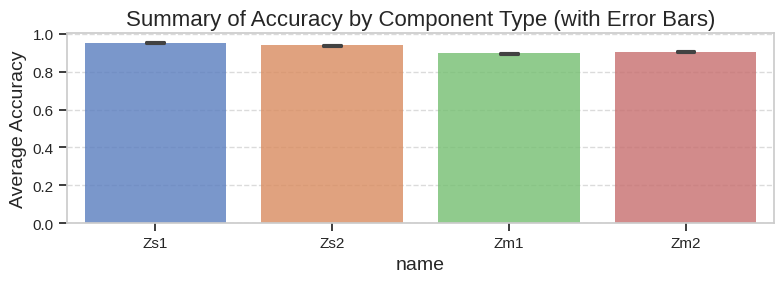


Summary of Accuracy by Component:
Zs1: 0.9533 ± 0.0415 (se: 0.0007)
Zs2: 0.9385 ± 0.0627 (se: 0.0011)
Zm2: 0.9048 ± 0.1012 (se: 0.0017)
Zm1: 0.8980 ± 0.0911 (se: 0.0015)


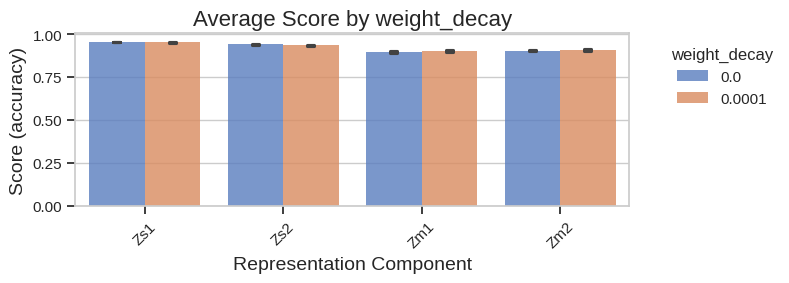

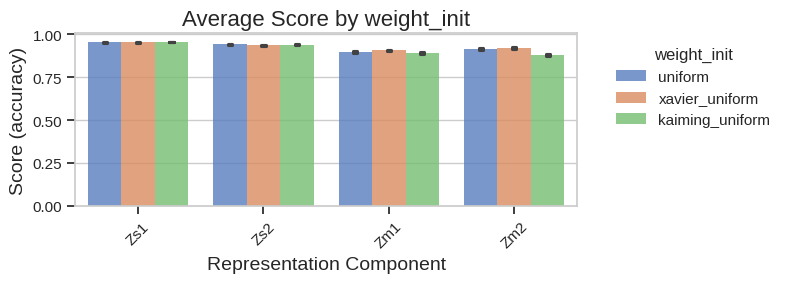

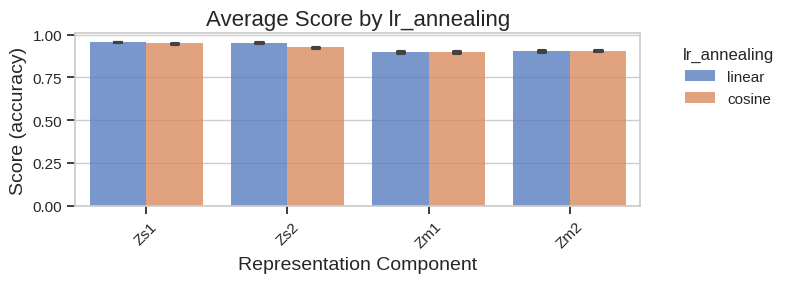

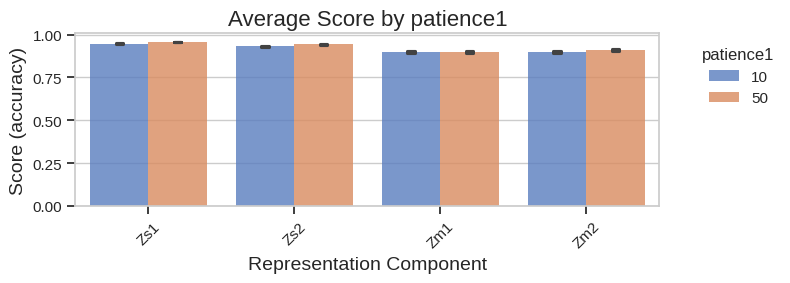

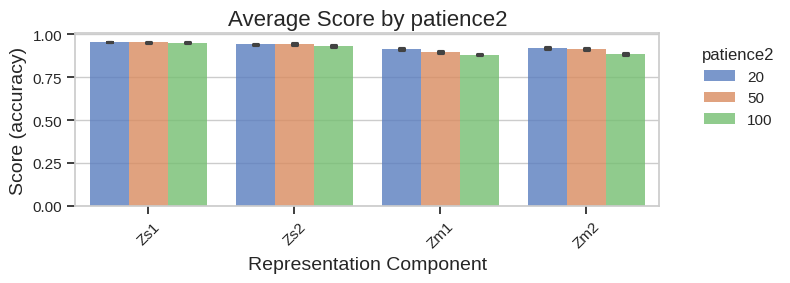

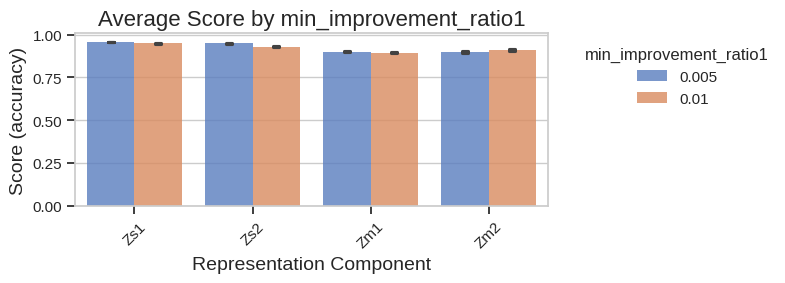

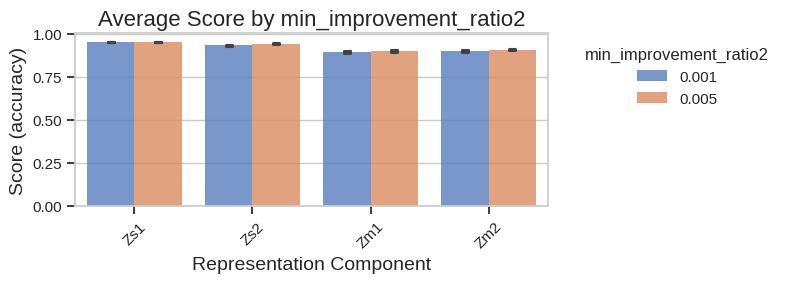

In [12]:
# Visualize classification performance by hyperparameters

# Create a summary bar plot of classification metrics by component type with error bars
if classification_df is not None:
    #metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metrics = ['accuracy']
    available_metrics = [m for m in metrics if m in classification_df.columns]
    
    for metric in available_metrics:
        plt.figure(figsize=(8, 3))
        
        # Group by component name and compute mean and std
        summary_data = classification_df.groupby('name')[metric].agg(['mean', 'std']).reset_index()
        
        # Sort by mean score for better visualization
        summary_data = summary_data.sort_values('mean', ascending=False)
        
        sns.barplot(x='name', y=metric, data=classification_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        
        plt.title(f'Summary of {metric.capitalize()} by Component Type (with Error Bars)')
        plt.ylabel(f'Average {metric.capitalize()}')
        #plt.xticks(range(len(summary_data)), summary_data['name'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Print numerical summary
        print(f"\nSummary of {metric.capitalize()} by Component:")
        for idx, row in summary_data.iterrows():
            print(f"{row['name']}: {row['mean']:.4f} ± {row['std']:.4f} (se: {row['std'] / np.sqrt(len(classification_df)):.4f})")

# Plot for each hyperparameter with multiple unique values
for param in hyperparams:
    plot_score_by_hyperparam(class_df_hyperparams, param, metric='accuracy')

## Predictability

In [13]:
# same for regression
# add the hyperparams to the regression data
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

regression_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the regression data
    regression_dfs_hyperparams.append(regression_df[regression_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
regression_df_hyperparams = pd.concat(regression_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
display(regression_df_hyperparams.head())

,name,r2_mean,r2_std,run_iter,seed,source_file,weight_decay,weight_init,lr_annealing,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2
0,Zm1,0.852005,0.123571,0,0,sim_sweep1_seed0_regression.csv,0.0001,uniform,linear,10,20,0.01,0.005
1,Zs1,0.720469,0.173813,0,0,sim_sweep1_seed0_regression.csv,0.0001,uniform,linear,10,20,0.01,0.005
2,(Zm+Zs)1,0.981080,0.014931,0,0,sim_sweep1_seed0_regression.csv,0.0001,uniform,linear,10,20,0.01,0.005
3,Zm2,0.807422,0.201352,0,0,sim_sweep1_seed0_regression.csv,0.0001,uniform,linear,10,20,0.01,0.005
4,Zs2,0.483459,0.350281,0,0,sim_sweep1_seed0_regression.csv,0.0001,uniform,linear,10,20,0.01,0.005


/tmp/ipykernel_1028117/2124191683.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y=metric, data=regression_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)


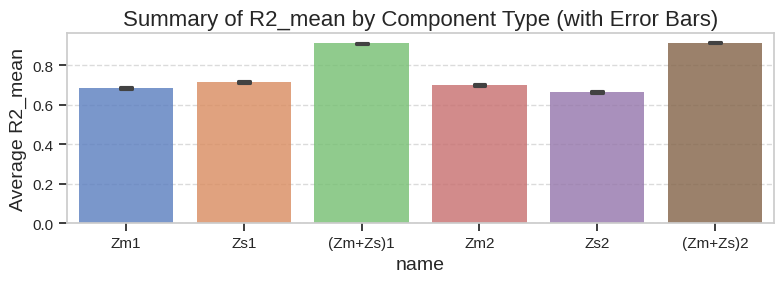


Summary of R2_mean by Component:
(Zm+Zs)2: 0.9139 ± 0.0728 / (se: 0.0010)
(Zm+Zs)1: 0.9121 ± 0.0757 / (se: 0.0011)
Zs1: 0.7155 ± 0.1317 / (se: 0.0018)
Zm2: 0.7022 ± 0.1344 / (se: 0.0019)
Zm1: 0.6865 ± 0.1580 / (se: 0.0022)
Zs2: 0.6627 ± 0.1438 / (se: 0.0020)


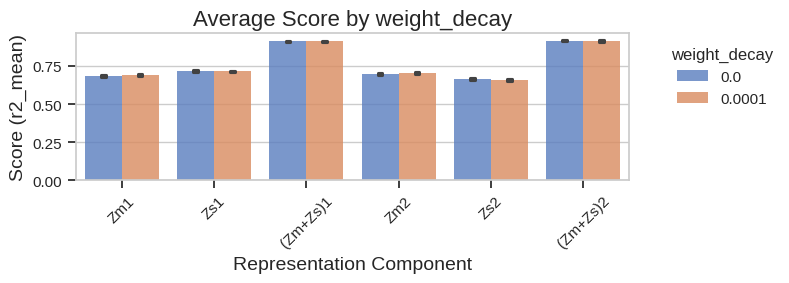

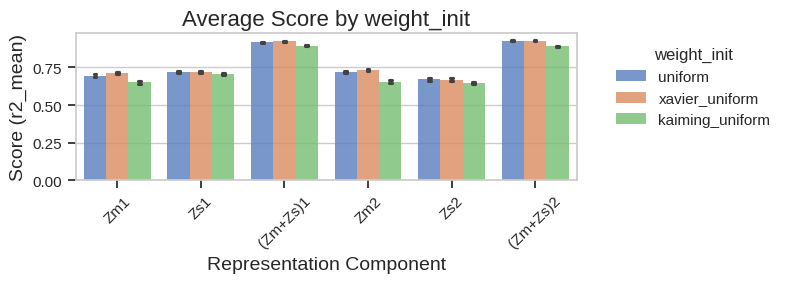

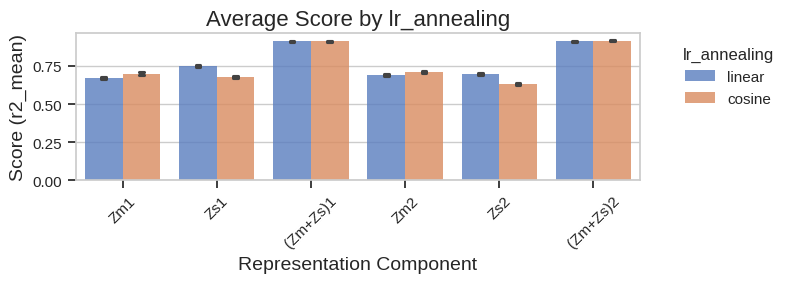

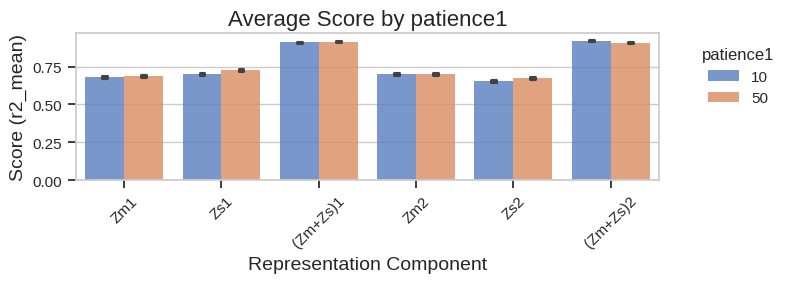

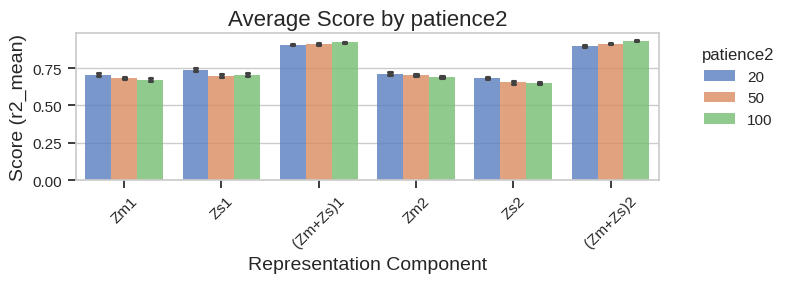

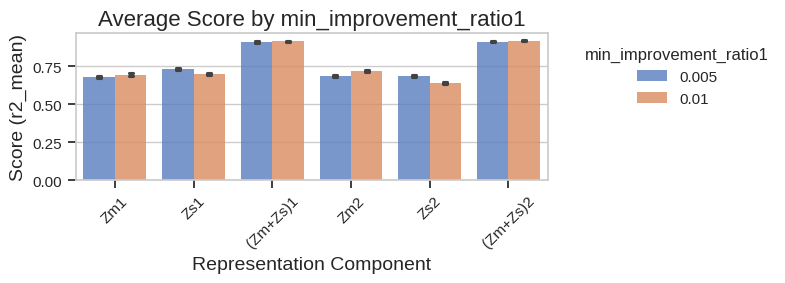

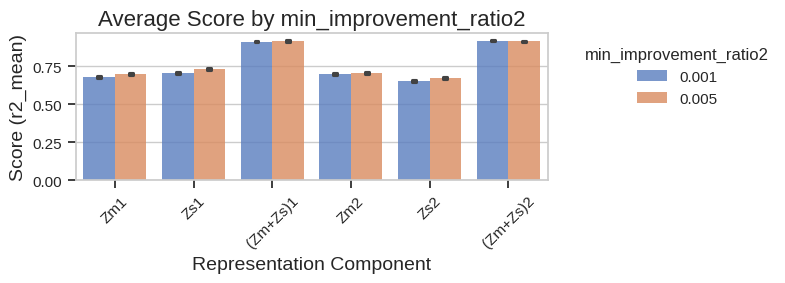

In [14]:
# plot
# Visualize regression performance by hyperparameters
# Create a summary bar plot of regression metrics by component type with error bars
if regression_df is not None:
    #metrics = ['r2_mean', 'r2_std', 'mae_mean', 'mae_std']
    metrics = ['r2_mean']
    available_metrics = [m for m in metrics if m in regression_df.columns]
    
    for metric in available_metrics:
        plt.figure(figsize=(8, 3))
        
        # Group by component name and compute mean and std
        summary_data = regression_df.groupby('name')[metric].agg(['mean', 'std']).reset_index()
        
        # Sort by mean score for better visualization
        summary_data = summary_data.sort_values('mean', ascending=False)
        
        sns.barplot(x='name', y=metric, data=regression_df, errorbar='se', palette='muted', capsize=0.1, alpha=0.8)
        
        plt.title(f'Summary of {metric.capitalize()} by Component Type (with Error Bars)')
        plt.ylabel(f'Average {metric.capitalize()}')
        #plt.xticks(range(len(summary_data)), summary_data['name'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Print numerical summary
        print(f"\nSummary of {metric.capitalize()} by Component:")
        for idx, row in summary_data.iterrows():
            print(f"{row['name']}: {row['mean']:.4f} ± {row['std']:.4f} / (se: {row['std'] / np.sqrt(len(regression_df)):.4f})")

# Plot for each hyperparameter with multiple unique values
for param in hyperparams:
    plot_score_by_hyperparam(regression_df_hyperparams, param, metric='r2_mean')

## Correlation and ranks

In [15]:
hyperparams = hyperparams_df.columns[:-2].tolist()
hyperparams = [hp for hp in hyperparams if len(train_df_hyperparams[hp].unique()) > 1]
hyperparams = [hp for hp in hyperparams if hp not in ['model_number', 'run_iter']]

corr_dfs_hyperparams = []
for run_iter in train_df['run_iter'].unique():
    # get the hyperparams for this run_iter
    hyperparams_run_iter = hyperparams_df[hyperparams_df['model_number'] == run_iter].iloc[0][hyperparams].to_dict()
    # add the hyperparams to the correlation data
    corr_dfs_hyperparams.append(rank_df[rank_df['run_iter'] == run_iter].assign(**hyperparams_run_iter))
corr_df_hyperparams = pd.concat(corr_dfs_hyperparams, ignore_index=True)
# filter the hyperparams to only those with more than 1 unique value
hyperparams = [hp for hp in hyperparams if len(corr_df_hyperparams[hp].unique()) > 1]
display(corr_df_hyperparams.head())

,name,metric,value,run_iter,seed,source_file,weight_decay,weight_init,lr_annealing,patience1,patience2,min_improvement_ratio1,min_improvement_ratio2
0,R_s-R_m1,correlation,-0.036224,0,0,sim_sweep1_seed0_analysis.csv,0.0001,uniform,linear,10,20,0.01,0.005
1,R_s-R_m2,correlation,-0.068096,0,0,sim_sweep1_seed0_analysis.csv,0.0001,uniform,linear,10,20,0.01,0.005
2,R_m1-R_m2,correlation,0.124011,0,0,sim_sweep1_seed0_analysis.csv,0.0001,uniform,linear,10,20,0.01,0.005
3,R_s,rank,2.000000,0,0,sim_sweep1_seed0_analysis.csv,0.0001,uniform,linear,10,20,0.01,0.005
4,R_m1,rank,4.000000,0,0,sim_sweep1_seed0_analysis.csv,0.0001,uniform,linear,10,20,0.01,0.005


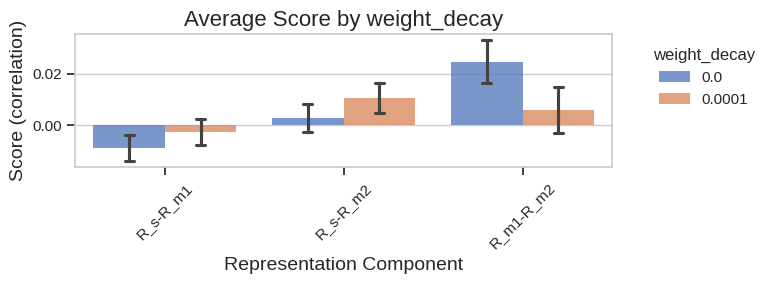

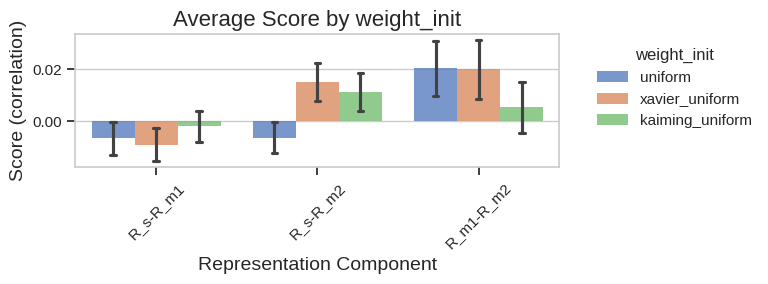

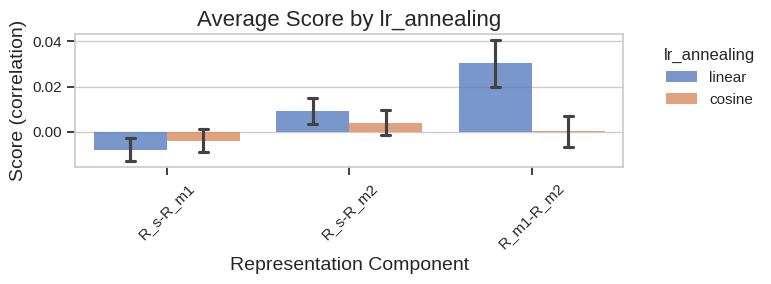

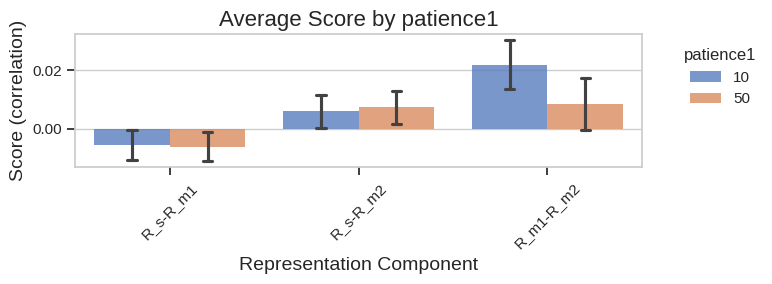

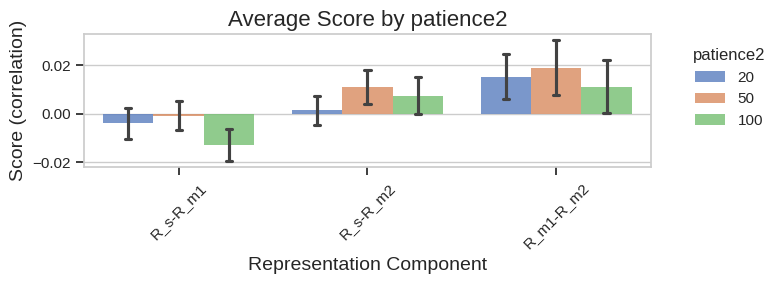

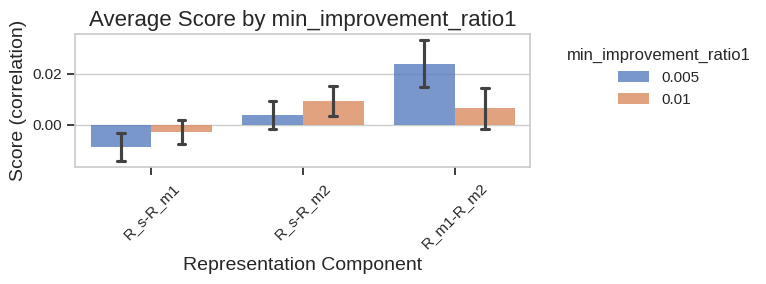

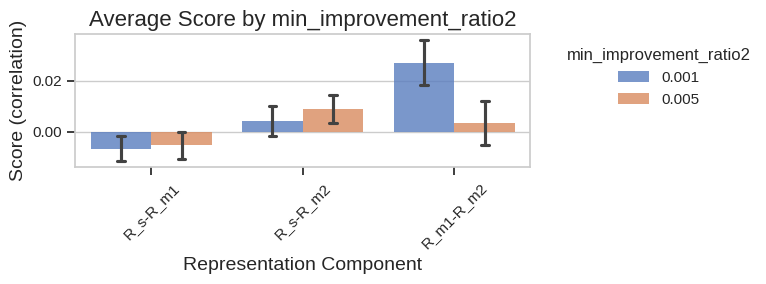

In [18]:
# plot correlation
# Visualize correlation performance by hyperparameters
for param in hyperparams:
    plot_score_by_hyperparam(corr_df_hyperparams, param, metric='correlation', metric_type='value')

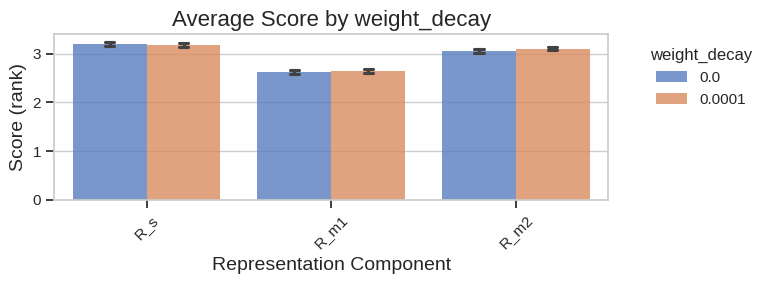

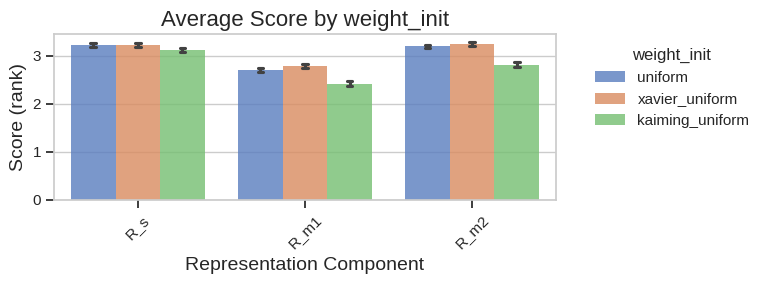

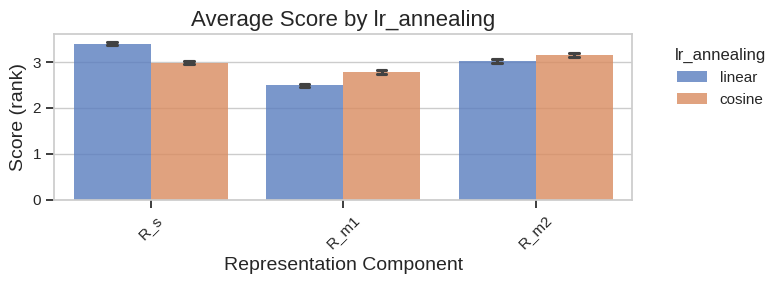

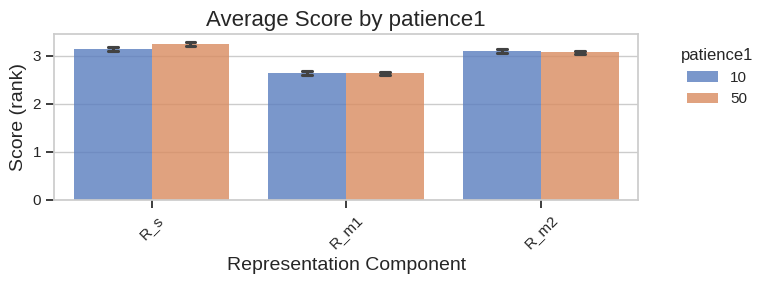

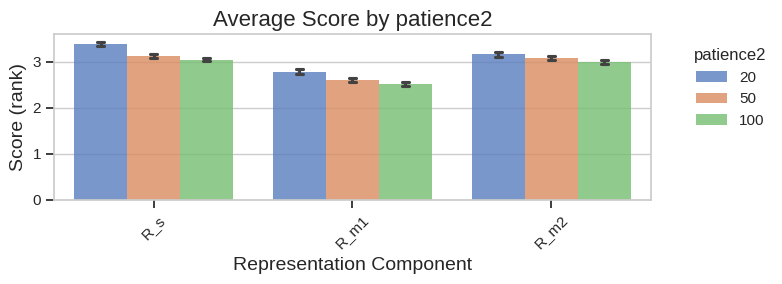

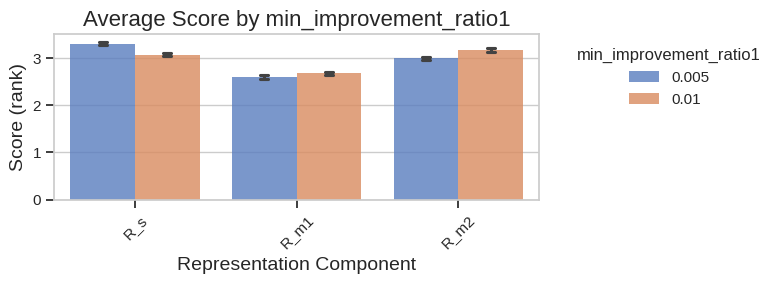

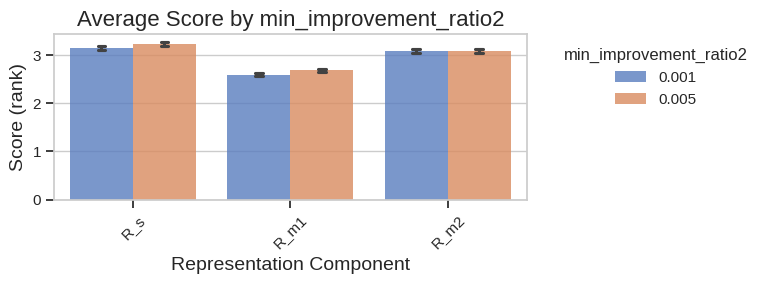

In [17]:
for param in hyperparams:
    plot_score_by_hyperparam(corr_df_hyperparams, param, metric='rank', metric_type='value')